In [1]:
words = open('names.txt', 'r').read().splitlines()
words[len(words) - 1000: len(words) - 990]

['jonahel',
 'jordanny',
 'jorgen',
 'jorniel',
 'josedavid',
 'josedejesus',
 'josephanthony',
 'josiaah',
 'josimar',
 'jourden']

(was in the middle of using a cities dataset in this folder, but using names for simplicyty, as cities required some cleaning up. I'll do a run for cities afterwards)

For a city, say, `minneapolis`, we have the following information within the word:
- m is a likely character to start the word
- i is a likely character to appear after m
- n is a likely character to appear after mi
- ...
- s is a likely character at which the word will end

Therefore, there's a lot packed into just one word, so we have to model the structure. Let's start working with a bigram language model for now.

## Bigram Language Model:
- word with 2 characters at a time (given one character, predict the next character)
- eg: what characters are likely to come after m
- very simple and weak language model, but a good start

### Bigram implementation:
- by frequency and using that as a probability (in these many cases, this preceeded this, so this should be the most likely outcome)

In [2]:
# example bigram frequency for just one word:

for w in words[:1]: # just one word for this example
    # sliding it through the words 2 char at a time:
    chars = ['<S>'] + list(w) + ['<E>'] # adding a start and end character
    
    for char_1, char_2 in zip(chars, chars[1:]): # two at a time
        print(char_1, char_2)

<S> e
e m
m m
m a
a <E>


In [3]:
# now, doing it for the entire dataset
bigram_frequency = {}

for w in words:
    # sliding it through the words 2 char at a time:
    chars = ['<S>'] + list(w) + ['<E>'] # adding a start and end character
    
    for char_1, char_2 in zip(chars, chars[1:]): # two at a time
        bigram = (char_1, char_2)

        # mapping bigram's frequency to get probability
        bigram_frequency[bigram] = bigram_frequency.get(bigram, 0) + 1

In [4]:
# sorted bigram (most likely bigrams):
sorted(bigram_frequency.items(), key=lambda x: x[1], reverse=True)
print("replace this print statement if you wanna see all the bigram's frequencies")

replace this print statement if you wanna see all the bigram's frequencies


We store this information of the frequency in a 2D array where:
- rows: first character of the bigram
- column: second character of the bigram
- each entry: tells us how often the second char follows the first char

Why even bother with 2D array:
- designing for pytorch api

In [5]:
import torch
# dealing with tensors (multidimensional arrays) 
# helps us to manipulate data very easily and efficiently

In [6]:
a = torch.zeros((3,5), dtype=torch.int32) # 3x5 array of zeroes (32 bit integers)
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [7]:
# tensor indexing, updating, etc is very efficient, like this:
a[1, 3] += 1
a[0, 0] = 5
a

tensor([[5, 0, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [8]:
# For our purposes:
# 26 letters + 2 special (starting and ending special)
# Therefore, 28x28 array:
N = torch.zeros((28, 28), dtype=torch.int32)

In [9]:
# need a lookup table to contain the frequency:

# 1. define the characters to map to
chars =sorted(list(set(''.join(words)))) # sorted list of all the characters

# 2. define the integer map table s -> i (mapping characters to integers)
s_to_i = {s: i for i, s in enumerate(chars)}
s_to_i['<S>'] = 26 # explicit mapping for special characters
s_to_i['<E>'] = 27

# 3. record the bigram frequencies by iterating through all words:
for w in words:
    # sliding it through the words 2 char at a time:
    chars = ['<S>'] + list(w) + ['<E>'] # adding a start and end character
    
    for char_1, char_2 in zip(chars, chars[1:]): # two at a time
        char1_idx = s_to_i[char_1]
        char2_idx = s_to_i[char_2]

        N[char1_idx, char2_idx] += 1

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

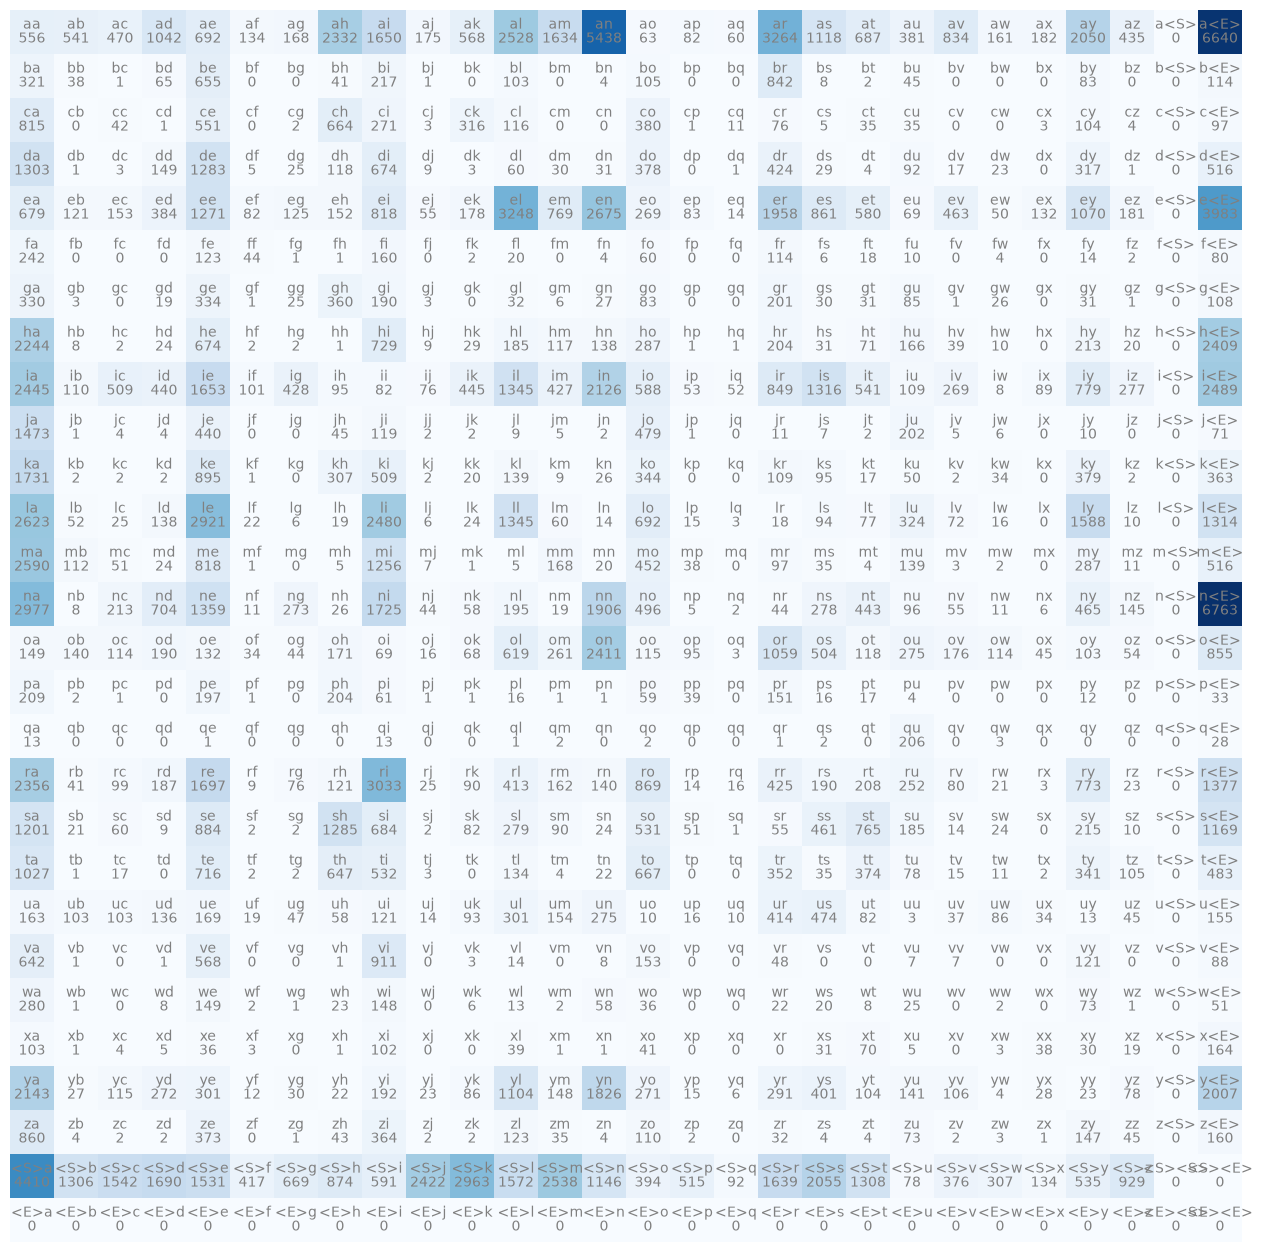

In [10]:
# Visualizing the 28x28 pytorch array:

import matplotlib.pyplot as plt
%matplotlib inline

i_to_s = {i:s for s, i in s_to_i.items()}
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(28):
    for j in range(28):
        chstr = i_to_s[i] + i_to_s[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color="gray")
plt.axis("off")

It can be clearly seen above, each cell in this 2D array stores:
- how many times that combination has occurred
- arrangement of rows and columns such that for N\[i, j], it's the frequency of character j appearing after character i

Problem with the current implementation:
- the explicit `<S>` and `<E>` character are making a lot of space in the array useless (space being reserved for S that's not the first character, and E that's the first character even though they're not possible)
- Solution: just have a single special character `.`

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

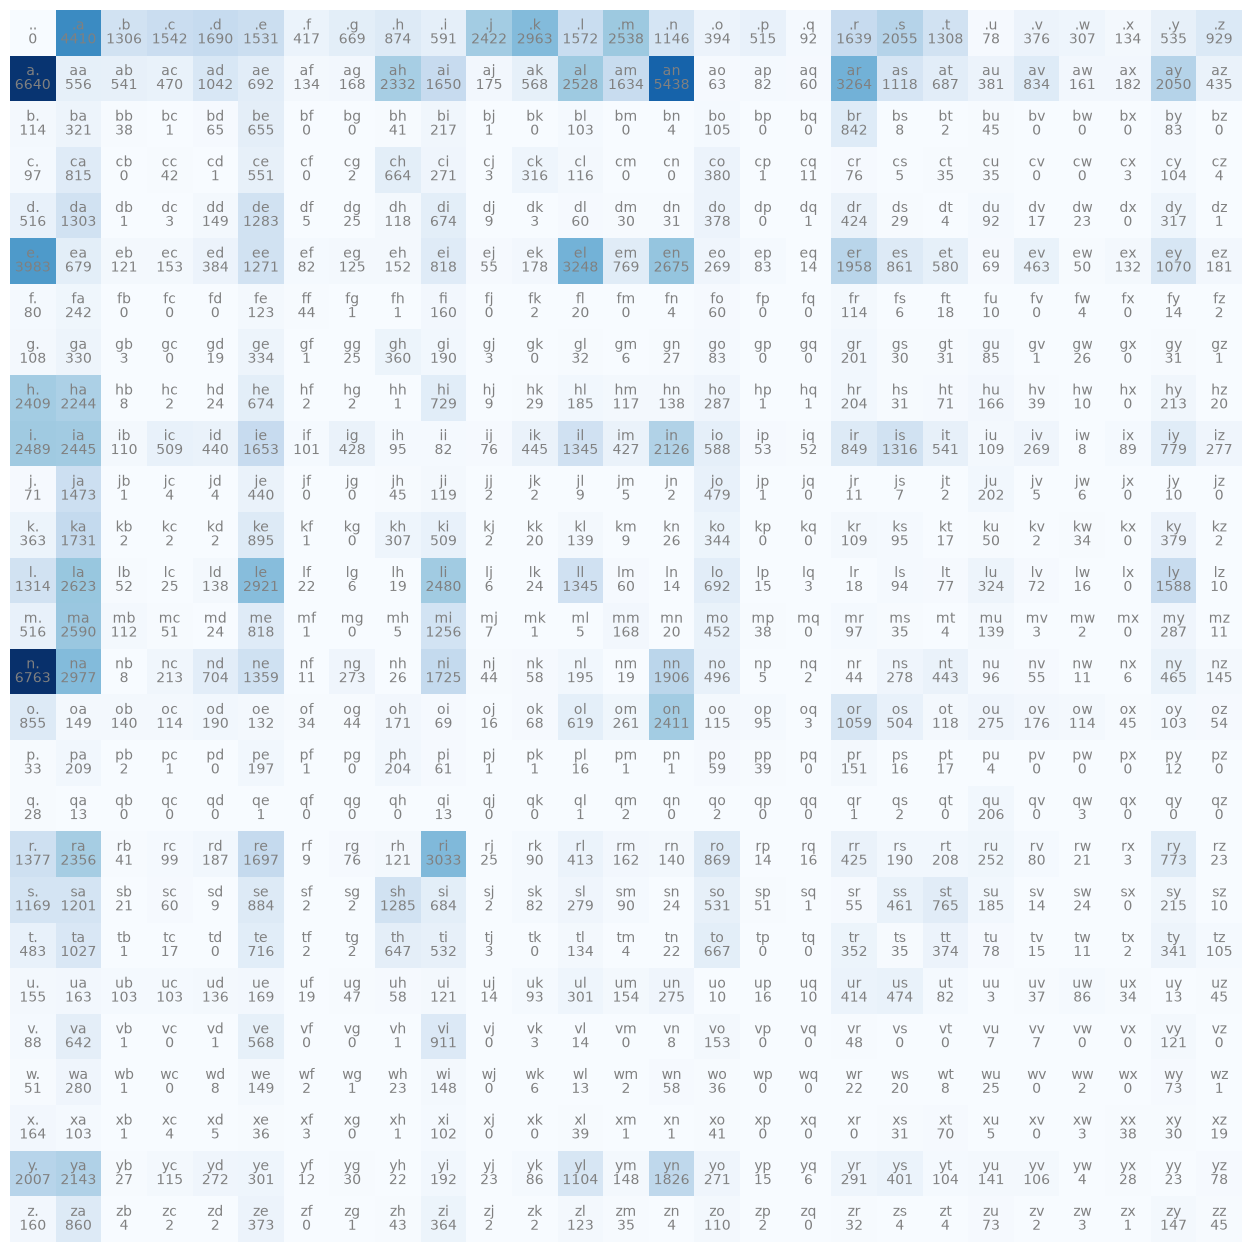

In [11]:
# updated using the new single special character:

N = torch.zeros((27, 27), dtype=torch.int32)
chars =sorted(list(set(''.join(words)))) # sorted list of all the characters

s_to_i = {s: i+1 for i, s in enumerate(chars)}
s_to_i['.'] = 0 # explicit mapping for special character
# shift s_to_i indexing by 1 to accomodate for special to have index 0

for w in words:
    chars = ['.'] + list(w) + ['.']
    
    for char_1, char_2 in zip(chars, chars[1:]): # two at a time
        char1_idx = s_to_i[char_1]
        char2_idx = s_to_i[char_2]

        N[char1_idx, char2_idx] += 1

# reverse mapping:
i_to_s = {i:s for s, i in s_to_i.items()}

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = i_to_s[i] + i_to_s[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color="gray")
plt.axis("off")

In [12]:
# This array now contains all the information that we need 
# to sample from this bigram model. 
# Now, just follow these probabilities while building the new words

# How we sample:

# 1. Get appropriate row (eg, for first char choose 0th row)
print('raw counts', N[0]) # first row contains probabilities of starting chars

# 2. now making a probability vector from the raw counts:
p = N[0].float() # why float? to normalize by dividing by sum
p = p / p.sum()

# 3. Sample from this probability distribution (pytorch multinomial api)
g = torch.Generator().manual_seed(2147483647) # generator object to make it deterministic
# generating a single char for the first letter based on proba distribution
selected_index = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
print('selected character', i_to_s[selected_index])

# why deterministic: so for tutorial his and our results can match

raw counts tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)
selected character c


In [ ]:
# Writing out the entire loop to generate words:
g = torch.Generator().manual_seed(2147483647) # generator object to make it deterministic

for i in range(10):
    generated_name = ""
    cur = 0 # beginning index 0
    while True:
        p = N[cur].float()
        p = p / p.sum()
        cur = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item() 
        generated_name += i_to_s[cur]
        # print(i_to_s[cur])
        if cur == 0:
            break # the special symbol encountered, so end word
    print(generated_name)
    

In [23]:
# Preparing a matrix of probabilities from N:
# (for efficiency so as to not do it over and over again in the loop)

# 1. Convert to float to be normalized by division:
P = N.float()

# 2. Finding row totals:
# we want to sum up over rows
# .sum() in tensor takes in the dimension to be summed against, as well as a keepdim
# dimension: sum all the rows to make just one column
# keepdim: don't let it turn into a 1D array, still want a 2D tensor with 1 col and 27 rows
# (we don't want 1D vector since we'll deal with 2D tensors)
row_totals = P.sum(1, keepdim=True) # get the sum of the 0th dimension (all rows)
# P now is a 2D tensor of shape (27,1) - column vector
print('2d tensor shape', row_totals.shape)

# 3. Dividing elements in each row by the row sum for normalization of each row:
# we can leverage pytorch's broadcasting logic (prerequisite: dimensions must roughly match)
# 27x27 and 27x1 roughly match (the 1 can be consolidated)
P = P / row_totals

print('sum of a row gives one because normalized', P[0].sum())



2d tensor shape torch.Size([27, 1])
sum of a row gives one because normalized tensor(1.)


In [19]:
# Writing out the entire loop to generate words:
g = torch.Generator().manual_seed(2147483647) # generator object to make it deterministic

for i in range(10):
    generated_name = ""
    cur = 0 # beginning index 0
    while True:
        p = N[cur].float()
        p = p / p.sum()
        cur = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item() 
        generated_name += i_to_s[cur]
        # print(i_to_s[cur])
        if cur == 0:
            break # the special symbol encountered, so end word
    print(generated_name)
    

torch.Size([27])